<a href="https://colab.research.google.com/github/marynatarasevych/ML_Study/blob/main/Tarasevych_%22HW_2_2_%D0%9F%D0%BE%D0%BB%D1%96%D0%BD%D0%BE%D0%BC%D1%96%D0%B0%D0%BB%D1%8C%D0%BD%D1%96_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%B8_Pipelines_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', lambda x: f'{x:,.2f}'.replace(',', ' '))

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Area under ROC score on Train dataset: 88.73%


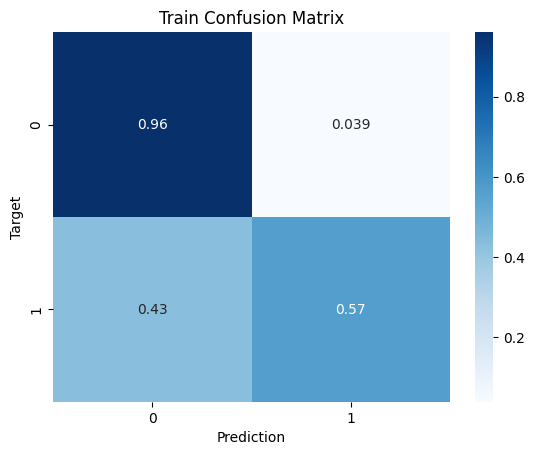

Area under ROC score on Validation dataset: 88.88%


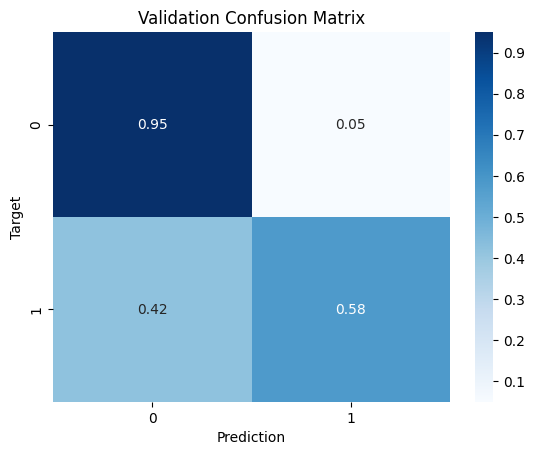

['model_bank_exited.joblib']

In [3]:
train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/Train Data.csv")
test_raw_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/Test Data.csv")
sample_submission = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/Sample Submission.csv")

train_df, val_df = train_test_split(train, test_size=0.20, random_state=42, stratify=train["Exited"])

# Створюємо трен. і вал. набори
cols_to_drop = ["id", "CustomerId", "Surname", "Exited"]
input_cols = train_df.drop(columns=cols_to_drop).columns.tolist()
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
# Створюємо функцію для генерування нових фічей (Gender_Type та Age_Group)
def map_gender(df):
    df = df.copy()
    gender_map = {'Male': 0, 'Female': 1}
    df['Gender_Type'] = df['Gender'].map(gender_map)
    return df

def add_age_group(df):
    bins = [18, 25, 35, 45, 55, 65, 100]
    labels = ['18-25', '25-35', '35-45', '45-55', '55-65', '65+']
    df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
    return df

feature_engineering = Pipeline(steps=[
    ('gender_map', FunctionTransformer(map_gender)),
    ('age_group', FunctionTransformer(add_age_group)),
])

# Оновлюємо список колонок
categorical_cols = categorical_cols + ['Age_Group']
numeric_cols = numeric_cols + ['Gender_Type']

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає фіча інженерінг і препроцесинг , потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('feature_engineering', feature_engineering),
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    probs = model_pipeline.predict_proba(inputs)[:, 1]
    roc_auc = roc_auc_score(targets, probs)
    print(f"Area under ROC score on {name} dataset: {roc_auc*100:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, name='Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, name='Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'model_bank_exited.joblib')


**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Train polynom_2 dataset: 92.47%


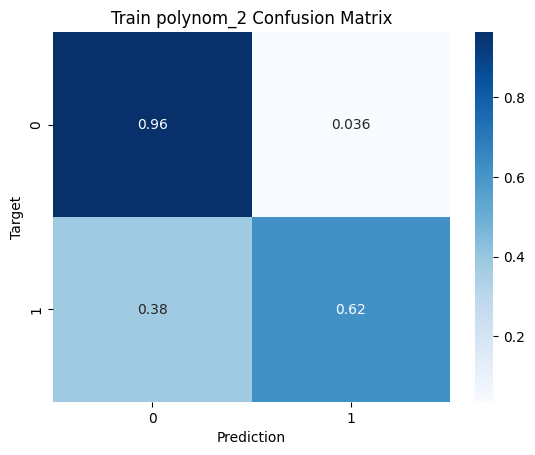

Area under ROC score on Validation polynom_2 dataset: 92.34%


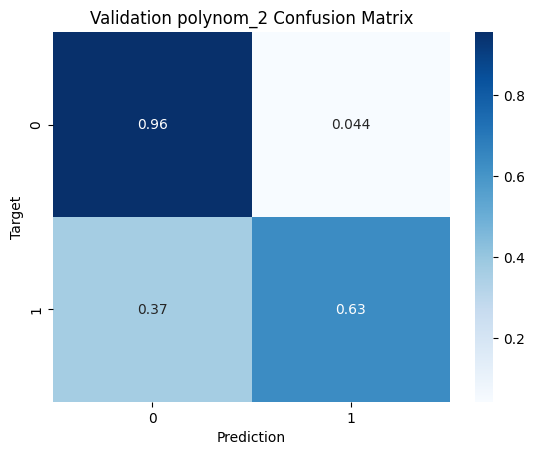

In [4]:
from sklearn.preprocessing import PolynomialFeatures

numeric_transformer_polynom_2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler()),
    ('polynom_2', PolynomialFeatures(degree=2))
])

preprocessor_polynom2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_polynom_2, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

model_pipeline_polynom2 = Pipeline(steps=[
    ('feature_engineering', feature_engineering),
    ('preprocessor', preprocessor_polynom2),
    ('classifier', LogisticRegression(solver='liblinear'))
])
model_pipeline_polynom2.fit(train_inputs, train_targets)

train_preds_p2 = predict_and_plot(model_pipeline_polynom2, train_inputs, train_targets, name='Train polynom_2')
val_preds_p2 = predict_and_plot(model_pipeline_polynom2, val_inputs, val_targets, name='Validation polynom_2')

**Висновок**

Модель з поліноміальними фічами до 2 степеня дає кращий результат, ROC AUC збільшився і на тренувальних (до 92,47%) і на валідаційних данних (до 92,34%). Розподіл спрогнозованих таргет 1 вже в більшій мірі попадає в правильне значення (recall класа 1 був 0,57, став 0,63, recall класа 0 - залишився майже таким самим). В цій моделі немає ні overfit ні underfit, вона добре генералізує.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Train polynom_4 dataset: 93.31%


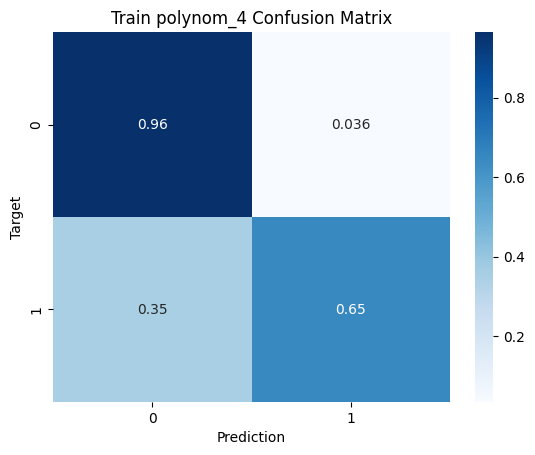

Area under ROC score on Validation polynom_4 dataset: 92.99%


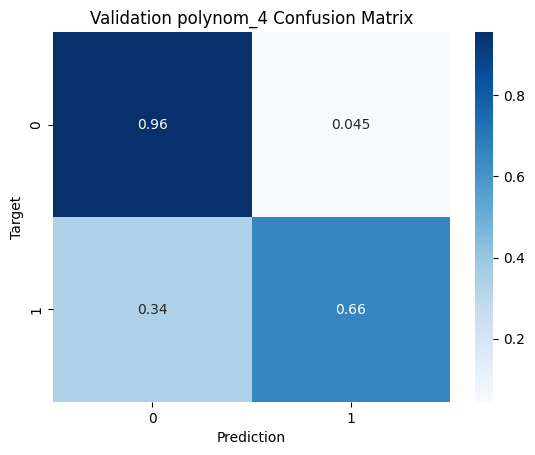

In [5]:
# для тестування що буде при 3 степені
numeric_transformer_polynom_3 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler()),
    ('polynom_3', PolynomialFeatures(degree=3))
])

preprocessor_polynom3 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_polynom_3, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

model_pipeline_polynom3 = Pipeline(steps=[
    ('feature_engineering', feature_engineering),
    ('preprocessor', preprocessor_polynom3),
    ('classifier', LogisticRegression(solver='liblinear'))
])
model_pipeline_polynom3.fit(train_inputs, train_targets)

train_preds_p3 = predict_and_plot(model_pipeline_polynom3, train_inputs, train_targets, name='Train polynom_4')
val_preds_p3 = predict_and_plot(model_pipeline_polynom3, val_inputs, val_targets, name='Validation polynom_4')

Area under ROC score on Train polynom_4 dataset: 93.55%


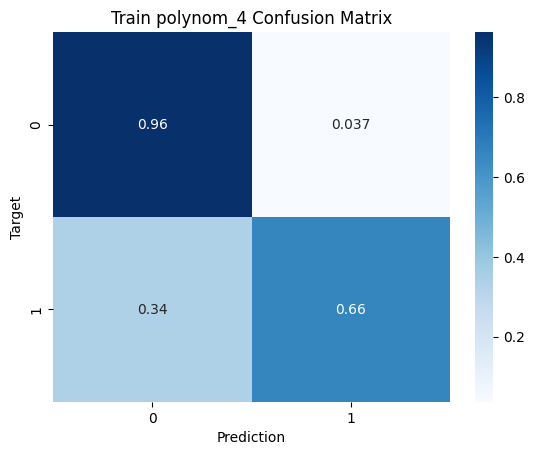

Area under ROC score on Validation polynom_4 dataset: 93.14%


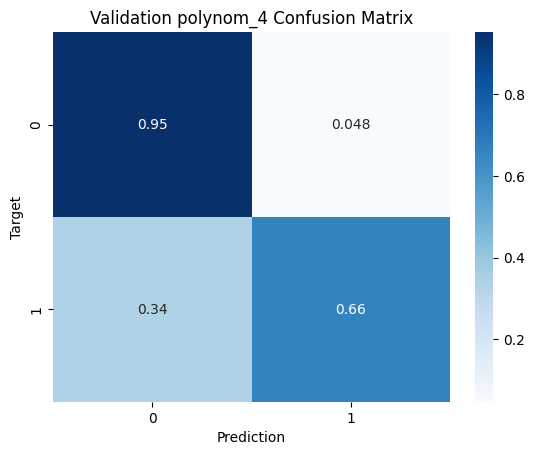

In [6]:
# 4 степінь
numeric_transformer_polynom_4 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler()),
    ('polynom_4', PolynomialFeatures(degree=4))
])

preprocessor_polynom4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_polynom_4, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

model_pipeline_polynom4 = Pipeline(steps=[
    ('feature_engineering', feature_engineering),
    ('preprocessor', preprocessor_polynom4),
    ('classifier', LogisticRegression(solver='liblinear'))
])
model_pipeline_polynom4.fit(train_inputs, train_targets)

train_preds_p4 = predict_and_plot(model_pipeline_polynom4, train_inputs, train_targets, name='Train polynom_4')
val_preds_p4 = predict_and_plot(model_pipeline_polynom4, val_inputs, val_targets, name='Validation polynom_4')

**Висновок**

Модель з поліноміальними фічами до 4 степеня дає змішаний результат. ROC AUC збільшився і на тренувальних і на валідаційних данних до 93,55% та 93,14% відповідно. Проте різниця в ROC AUC між трейном і валідацією в моделі з поліномом 2 була 0,13 п.п. (92.47 - 92,34), а стала 0,41 п.п. (93,55 - 93,14)

При цьому recoll 1 класу покращився і став 0,66, recall класа 0 - майже не змінився

Зібльшення різниці в ROC AUC між трейном і валідацією говорть про початок перенавчання і далі збільшувати степінь поліному не потрібно.

Area under ROC score on Train dataset: 93.62%


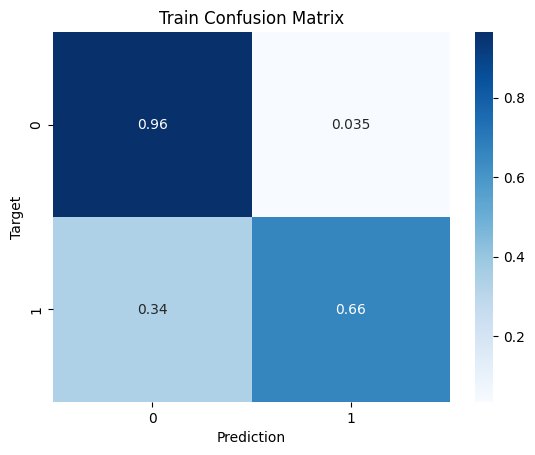

Area under ROC score on Validation dataset: 93.03%


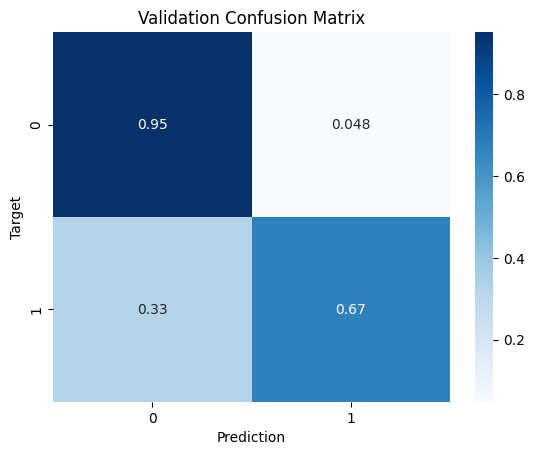

['model_bank_exited_v2.joblib']

In [7]:
# тестування нових фічей
# 3 - 93.31% / 92.99%
# 4 - 93.55% / 93.14%
# new_features - 93.62% / 93.03 %

def new_features(X):
    # Баланс відносно зарплати
    X['Balance_to_Salary'] = X['Balance'] / (X['EstimatedSalary'] + 1) #93.32% / 92.96%
    # Чи є взагалі баланс
    X['HasZeroBalance'] = (X['Balance'] == 0).astype(int) #93.44% / 92.99%
    # Products per tenure
    X['Products_per_Tenure'] = X['NumOfProducts'] / (X['Tenure'] + 1) #93.52% / 93.00%
    # Комбинація активності та наявності карти
    X['Active_and_HasCard'] = X['IsActiveMember'] * X['HasCrCard'] #93.58% / 93.00%
    # Клієнт з 1 продуктом та неактивний
    X['Risk_Flag'] = ((X['NumOfProducts'] == 1) & (X['IsActiveMember'] == 0)).astype(int) #без бинов 93.58% / 93.03%
    # Клієнт в віці з малим tenure
    X['New_Senior'] = ((X['Age'] > 50) & (X['Tenure'] < 2)).astype(int) #93.62% / 93.03%
    return X

feature_engineering = Pipeline(steps=[
    ('gender_map', FunctionTransformer(map_gender)),
    ('age_group', FunctionTransformer(add_age_group)),
    ('new_features', FunctionTransformer(new_features)),
])

#93.55% / 93.14%
# Оновлюємо список колонок
categorical_cols = categorical_cols + ['Age_Group']
numeric_cols = numeric_cols + ['Gender_Type'] + ['Balance_to_Salary'] + ['HasZeroBalance'] + ['Products_per_Tenure'] + ['Active_and_HasCard'] + ['Risk_Flag'] + ['New_Senior']

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler()),
    ('polynom_3', PolynomialFeatures(degree=3))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає фіча інженерінг і препроцесинг , потім тренуєм модель
model_pipeline_v2 = Pipeline(steps=[
    ('feature_engineering', feature_engineering),
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline_v2.fit(train_inputs, train_targets)

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline_v2, train_inputs, train_targets, name='Train')
val_preds = predict_and_plot(model_pipeline_v2, val_inputs, val_targets, name='Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline_v2, 'model_bank_exited_v2.joblib')


In [8]:
test_inputs = test_raw_df[input_cols].copy()
test_raw_df['Exited'] = model_pipeline_v2.predict_proba(test_inputs)[:, 1]
test_raw_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15 594 796.00,Chu,584.00,Germany,Male,30.00,2.00,146 053.66,1.00,1.00,1.00,157 891.86,0.11
1,15001,15 642 821.00,Mazzi,551.00,France,Male,39.00,5.00,0.00,2.00,1.00,1.00,67 431.28,0.02
2,15002,15 716 284.00,Onyekachi,706.00,France,Male,43.00,8.00,0.00,2.00,1.00,0.00,156 768.45,0.05
3,15003,15 785 078.00,Martin,717.00,Spain,Male,45.00,3.00,0.00,1.00,1.00,1.00,166 909.87,0.32
4,15004,15 662 955.00,Kenechukwu,592.00,Spain,Male,43.00,8.00,0.00,2.00,1.00,1.00,143 681.97,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,15 642 997.00,Chukwumaobim,639.00,Spain,Male,38.00,10.00,0.00,2.00,1.00,1.00,49 637.65,0.01
9996,24996,15 739 271.00,Clements,678.00,Spain,Male,39.00,9.00,0.00,2.00,1.00,1.00,142 513.50,0.01
9997,24997,15 756 743.00,Chidiebere,774.00,France,Male,30.00,9.00,0.00,2.00,1.00,0.00,4 861.72,0.01
9998,24998,15 680 167.00,Yermakova,595.00,France,Male,38.00,6.00,144 875.79,1.00,1.00,0.00,126 469.09,0.13


In [9]:
sample_submission['Exited'] = test_raw_df['Exited']
sample_submission.to_csv('/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/submission_log_reg_v2.csv', index=False)

In [10]:
# додавання моделей регуляції до змагання Kaggle
# new_features - 93.62% / 93.03 %
classifiers = [
    ('LogReg L2 (default)', LogisticRegression(penalty='l2', C=1.0, solver='liblinear')),
    ('LogReg L2 strong', LogisticRegression(penalty='l2', C=0.1, solver='liblinear')),
    ('LogReg L1', LogisticRegression(penalty='l1', C=1.0, solver='liblinear')),
    ('LogReg L1 strong', LogisticRegression(penalty='l1', C=0.1, solver='liblinear')),
    #('LogReg ElasticNet', LogisticRegression(penalty='elasticnet', C=1.0, l1_ratio=0.5, solver='saga', max_iter=5000)), - тестувала, довго думає і не дає гарного результату
]

results = []

for name, clf in classifiers:
    model_pipeline_test = Pipeline(steps=[
        ('feature_engineering', feature_engineering),
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])

    model_pipeline_test.fit(train_inputs, train_targets)

    train_probs = model_pipeline_test.predict_proba(train_inputs)[:, 1]
    val_probs = model_pipeline_test.predict_proba(val_inputs)[:, 1]

    train_auc = roc_auc_score(train_targets, train_probs)
    val_auc = roc_auc_score(val_targets, val_probs)

    results.append({'model': name, 'train_auc': train_auc, 'val_auc': val_auc, 'gap': train_auc - val_auc})
    print(f"{name}: train AUC={train_auc:.4f}, val AUC={val_auc:.4f}, gap={train_auc - val_auc:.4f}")

results_df = pd.DataFrame(results).sort_values('val_auc', ascending=False)
results_df

LogReg L2 (default): train AUC=0.9362, val AUC=0.9303, gap=0.0059
LogReg L2 strong: train AUC=0.9254, val AUC=0.9212, gap=0.0042
LogReg L1: train AUC=0.9358, val AUC=0.9326, gap=0.0031
LogReg L1 strong: train AUC=0.9272, val AUC=0.9256, gap=0.0016


,model,train_auc,val_auc,gap
2,LogReg L1,0.94,0.93,0.00
0,LogReg L2 (default),0.94,0.93,0.01
3,LogReg L1 strong,0.93,0.93,0.00
1,LogReg L2 strong,0.93,0.92,0.00


In [11]:
# Об'єднання train и val для фінального навчання перед сабмітом
full_inputs = pd.concat([train_inputs, val_inputs])
full_targets = pd.concat([train_targets, val_targets])

model_pipeline_v3 = Pipeline(steps=[
    ('feature_engineering', feature_engineering),
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(penalty='l1', C=1.0, solver='liblinear'))
])
model_pipeline_v3.fit(full_inputs, full_targets)

Pipeline(steps=[('feature_engineering',
                 Pipeline(steps=[('gender_map',
                                  FunctionTransformer(func=<function map_gender at 0x7eeae3178f40>)),
                                 ('age_group',
                                  FunctionTransformer(func=<function add_age_group at 0x7eeae3178e00>)),
                                 ('new_features',
                                  FunctionTransformer(func=<function new_features at 0x7eeae0ce3b00>))])),
                ('preprocessor',
                 ColumnTransformer(transformers=[('nu...
                                                   'HasZeroBalance',
                                                   'Products_per_Tenure',
                                                   'Active_and_HasCard',
                                                   'Risk_Flag', 'New_Senior']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Geography', 'Gender',
                                                   'Age_Group',
                                                   'Age_Group'])])),
                ('classifier',
                 LogisticRegression(penalty='l1', solver='liblinear'))])

In [12]:
logreg_l1 = model_pipeline_v3.named_steps['classifier']
coefs = logreg_l1.coef_[0]
print(f"Всего коэффициентов: {len(coefs)}, обнулено: {np.sum(coefs == 0)}")

Всего коэффициентов: 986, обнулено: 820


In [13]:
test_raw_df_v3 = test_raw_df.copy()
test_raw_df_v3['Exited'] = model_pipeline_v3.predict_proba(test_inputs)[:, 1]
test_raw_df_v3

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15 594 796.00,Chu,584.00,Germany,Male,30.00,2.00,146 053.66,1.00,1.00,1.00,157 891.86,0.13
1,15001,15 642 821.00,Mazzi,551.00,France,Male,39.00,5.00,0.00,2.00,1.00,1.00,67 431.28,0.01
2,15002,15 716 284.00,Onyekachi,706.00,France,Male,43.00,8.00,0.00,2.00,1.00,0.00,156 768.45,0.05
3,15003,15 785 078.00,Martin,717.00,Spain,Male,45.00,3.00,0.00,1.00,1.00,1.00,166 909.87,0.35
4,15004,15 662 955.00,Kenechukwu,592.00,Spain,Male,43.00,8.00,0.00,2.00,1.00,1.00,143 681.97,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,15 642 997.00,Chukwumaobim,639.00,Spain,Male,38.00,10.00,0.00,2.00,1.00,1.00,49 637.65,0.01
9996,24996,15 739 271.00,Clements,678.00,Spain,Male,39.00,9.00,0.00,2.00,1.00,1.00,142 513.50,0.01
9997,24997,15 756 743.00,Chidiebere,774.00,France,Male,30.00,9.00,0.00,2.00,1.00,0.00,4 861.72,0.00
9998,24998,15 680 167.00,Yermakova,595.00,France,Male,38.00,6.00,144 875.79,1.00,1.00,0.00,126 469.09,0.12


In [14]:
sample_submission['Exited'] = test_raw_df_v3['Exited']
sample_submission.to_csv('/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/submission_log_reg_v3.csv', index=False)

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


Train RMSE: 0.00
Train MAE: 0.00
Train R²: 1.0000


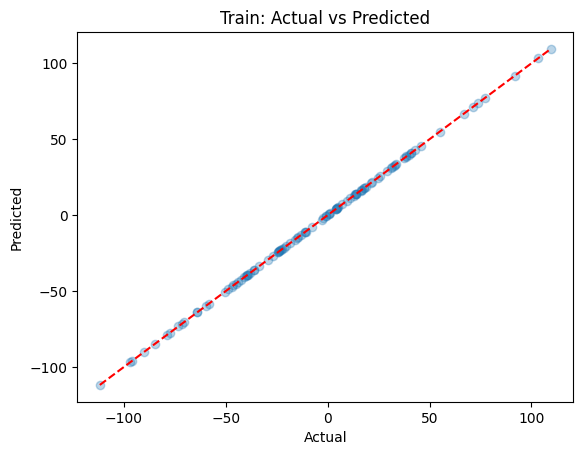

Validation RMSE: 17.35
Validation MAE: 10.83
Validation R²: 0.8710


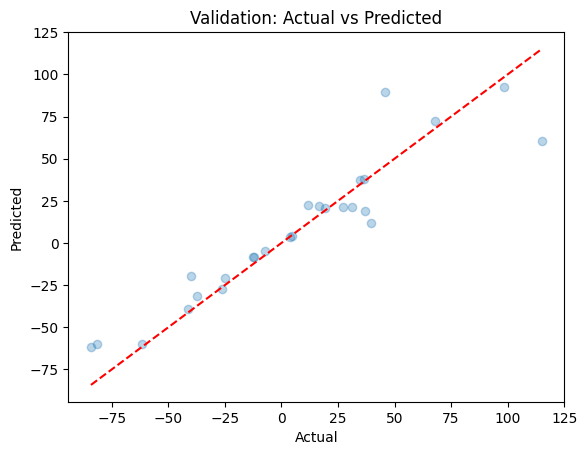

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

regression_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Regression Data.csv")
train_df, val_df = train_test_split(regression_data, test_size=0.20, random_state=42)

# Створюємо трен. і вал. набори
input_cols = train_df.drop(columns=['target']).columns.tolist()
target_col = 'target'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler()),
    ('polynom_3', PolynomialFeatures(degree=5))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає фіча інженерінг і препроцесинг , потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

#Функція оцінки
def predict_and_evaluate_regression(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)

    rmse = np.sqrt(mean_squared_error(targets, preds))

    print(f"{name} RMSE: {rmse:.2f}")

    plt.figure()
    plt.scatter(targets, preds, alpha=0.3)
    plt.plot([targets.min(), targets.max()], [targets.min(), targets.max()], 'r--')  # линия идеального предсказания
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{name}: Actual vs Predicted')
    plt.show()

    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_evaluate_regression(model_pipeline, train_inputs, train_targets, name='Train')
val_preds = predict_and_evaluate_regression(model_pipeline, val_inputs, val_targets, name='Validation')

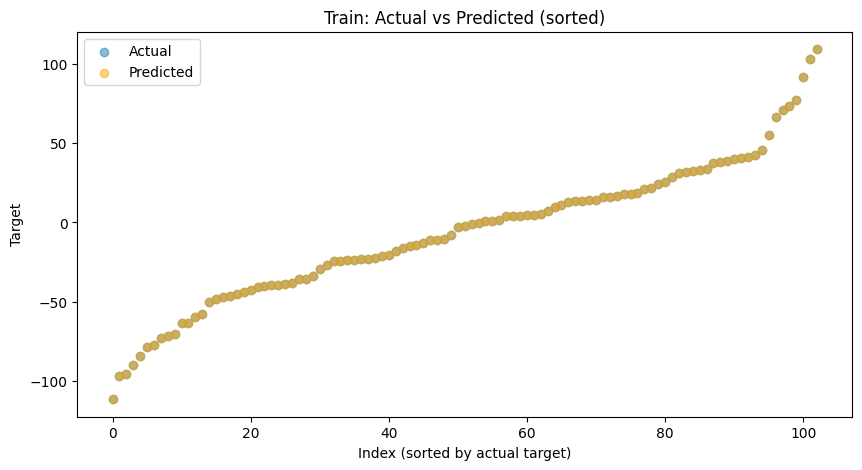

In [28]:
sort_idx = train_targets.values.argsort()

train_preds = model_pipeline.predict(train_inputs)

plt.figure(figsize=(10, 5))
plt.scatter(range(len(train_targets)), train_targets.values[sort_idx], alpha=0.5, label='Actual')
plt.scatter(range(len(train_targets)), train_preds[sort_idx], alpha=0.5, label='Predicted', color='orange')
plt.xlabel('Index (sorted by actual target)')
plt.ylabel('Target')
plt.title('Train: Actual vs Predicted (sorted)')
plt.legend()
plt.show()

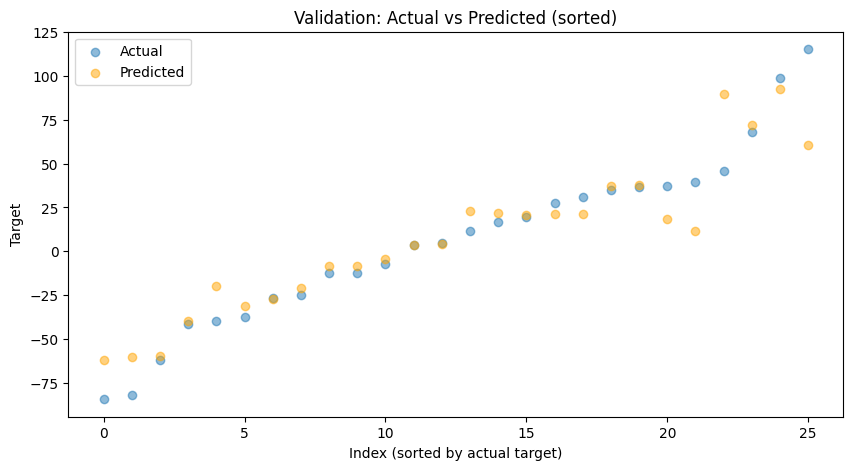

In [29]:
sort_idx_val = val_targets.values.argsort()

val_preds = model_pipeline.predict(val_inputs)

plt.figure(figsize=(10, 5))
plt.scatter(range(len(val_targets)), val_targets.values[sort_idx_val], alpha=0.5, label='Actual')
plt.scatter(range(len(val_targets)), val_preds[sort_idx_val], alpha=0.5, label='Predicted', color='orange')
plt.xlabel('Index (sorted by actual target)')
plt.ylabel('Target')
plt.title('Validation: Actual vs Predicted (sorted)')
plt.legend()
plt.show()

**Висновок**

RMSE для тренувального набору = 0.00, а для валідаційного - 17,35. Це значить, що модель повністю вивчила дані тренувального набору і зовсім не може робити предикт на валідаційних. Модель перенавчена і погано генералізцє

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [36]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
import warnings
warnings.filterwarnings("ignore")

models = [
    LinearRegression(),
    Ridge(),
    Ridge(alpha=2),
    Lasso(),
    ElasticNet(),
    ElasticNet(alpha=0.5)
]

def evaluate_model(model, X_train, y_train, X_val, y_val):
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_metrics = np.sqrt(mean_squared_error(y_train, y_train_pred)).round(6)
    val_metrics = np.sqrt(mean_squared_error(y_val, y_val_pred)).round(6)

    return dict(train=train_metrics, val=val_metrics)

scaler = MinMaxScaler()
train_inputs_scaled = scaler.fit_transform(train_inputs)
val_inputs_scaled = scaler.transform(val_inputs)

poly_features = PolynomialFeatures(degree=20)
train_inputs_poly = poly_features.fit_transform(train_inputs_scaled)
val_inputs_poly = poly_features.transform(val_inputs_scaled)

for model in models:
    model.fit(train_inputs_poly, train_targets)
    eval_results  = evaluate_model(model, train_inputs_poly, train_targets, val_inputs_poly, val_targets)
    print(f'{str(model)}: {eval_results}\n')

LinearRegression(): {'train': np.float64(0.0), 'val': np.float64(12.734214)}

Ridge(): {'train': np.float64(5.885065), 'val': np.float64(7.02105)}

Ridge(alpha=2): {'train': np.float64(7.92074), 'val': np.float64(8.614413)}

Lasso(): {'train': np.float64(5.098171), 'val': np.float64(5.671931)}

ElasticNet(): {'train': np.float64(30.034532), 'val': np.float64(30.442414)}

ElasticNet(alpha=0.5): {'train': np.float64(23.835943), 'val': np.float64(23.298833)}



**Висновок**

Модель Lasso дає найкращий результат: В неї найменший RMSE на обох наборах і між трейном і валідацією наймента різниця (5,67 - 5,1 = 0,57). При degree 20 створюється велика кількість повторювальних ознак, а модель Lasso обнуляє коефіцієнти непотрібнийх.

In [38]:
lasso_model = [m for m in models if isinstance(m, Lasso) and m.alpha == 1.0][0]  # или явно найдите Lasso() в списке
n_total = len(lasso_model.coef_)
n_zero = np.sum(lasso_model.coef_ == 0)
print(f"Всього коефіцієнтів: {n_total}, обнулено: {n_zero} ({n_zero/n_total*100:.1f}%)")

Всього коефіцієнтів: 53130, обнулено: 53129 (100.0%)


In [39]:
nonzero_idx = np.where(lasso_model.coef_ != 0)[0]
feature_names = poly_features.get_feature_names_out()
print("Оставшийся признак:", feature_names[nonzero_idx])
print("Его коэффициент:", lasso_model.coef_[nonzero_idx])
print("Intercept:", lasso_model.intercept_)

Оставшийся признак: ['x3']
Его коэффициент: [194.92924809]
Intercept: -98.6841819351067


In [42]:
regression_data.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.19,-1.38,-0.88,0.54,-1.04,28.94
1,-0.32,-0.56,0.41,-0.15,-0.83,-7.66
2,2.12,-1.52,1.03,-1.26,0.92,-63.85
3,-1.38,-0.06,-1.70,0.07,1.63,4.08
4,-0.07,-1.51,-0.85,0.71,0.47,34.88


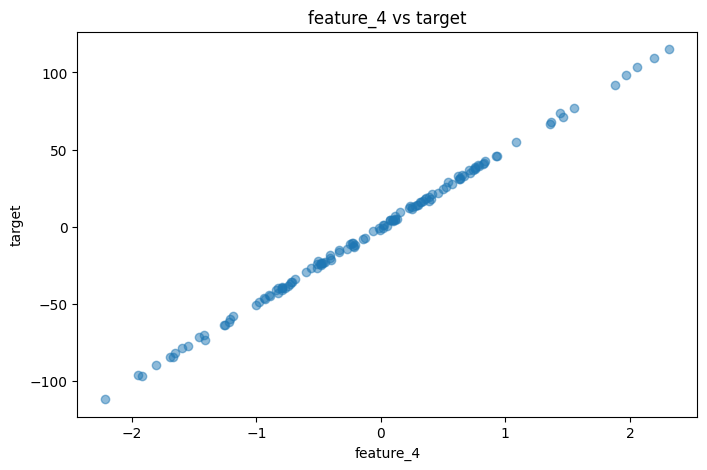

In [41]:
plt.figure(figsize=(8, 5))
plt.scatter(regression_data['feature_4'], regression_data['target'], alpha=0.5)
plt.xlabel('feature_4')
plt.ylabel('target')
plt.title('feature_4 vs target')
plt.show()

**Висновок**
Модель Lasso вбила всі параметри, створенні поліномом, і навіть вхідні перші 3 ознаки, залишивши тільки feature_4 та інтерсептор. Графік feature_4 та target показує просту лінійну модель з 1 ознакою